In [1]:
# Import robot_python_code.py
from robot_python_code import DataLoader

# Inches to Meters 
inches_to_meters = 0.0254

# Distance in inches
files_and_data = [
    ['robot_data_70_0_12_02_26_19_09_16.pkl', 5000, 48 + 1/4],
    ['robot_data_70_0_12_02_26_19_12_32.pkl', 5000, 49 + 7/8],
    ['robot_data_70_0_12_02_26_19_14_16.pkl', 5000, 49 + 5/8],
    ['robot_data_70_0_12_02_26_19_16_32.pkl', 10000, 98],
    ['robot_data_70_0_12_02_26_19_18_50.pkl', 10000, 100.5],
    ['robot_data_70_0_12_02_26_19_21_16.pkl', 10000, 99],
    ['robot_data_70_0_12_02_26_19_23_39.pkl', 15000, 150],
    ['robot_data_70_0_12_02_26_19_26_05.pkl', 15000, 149],
    ['robot_data_70_0_12_02_26_19_27_27.pkl', 15000, 149],
]


In [2]:
trial_data = []

for file, time, distance in files_and_data:
    data = DataLoader('./data_straight_final/' + file).load()
    encoder_counts = abs(data['robot_sensor_signal'][-1].encoder_counts - data['robot_sensor_signal'][0].encoder_counts)
    speed, steer = data['control_signal'][0]
    trial_data.append({'encoder_counts' : encoder_counts, 'distance' : distance * inches_to_meters, 'speed': speed, 'steer': steer, 'time': time })

trial_data = sorted(trial_data, key=lambda x: x['encoder_counts'])
print(*trial_data, sep="\n")


{'encoder_counts': 4417, 'distance': 1.22555, 'speed': 70, 'steer': 0, 'time': 5000}
{'encoder_counts': 4528, 'distance': 1.260475, 'speed': 70, 'steer': 0, 'time': 5000}
{'encoder_counts': 4543, 'distance': 1.2668249999999999, 'speed': 70, 'steer': 0, 'time': 5000}
{'encoder_counts': 9027, 'distance': 2.4892, 'speed': 70, 'steer': 0, 'time': 10000}
{'encoder_counts': 9059, 'distance': 2.5145999999999997, 'speed': 70, 'steer': 0, 'time': 10000}
{'encoder_counts': 9179, 'distance': 2.5526999999999997, 'speed': 70, 'steer': 0, 'time': 10000}
{'encoder_counts': 13630, 'distance': 3.7845999999999997, 'speed': 70, 'steer': 0, 'time': 15000}
{'encoder_counts': 13669, 'distance': 3.7845999999999997, 'speed': 70, 'steer': 0, 'time': 15000}
{'encoder_counts': 13723, 'distance': 3.81, 'speed': 70, 'steer': 0, 'time': 15000}


In [3]:
# Make plots interactive in the notebook
import matplotlib.pyplot as plt

x_data = [trial['encoder_counts'] for trial in trial_data]
y_data = [trial['distance'] for trial in trial_data]

print(x_data)
print(y_data)

# plt.xlabel(f'Encoder Count $e$')
# plt.ylabel(f'Distance $s$ (meters)')
# plt.title('Distance Traveled vs Encoder Count')

# plt.plot(x_data, y_data, marker='o')

[4417, 4528, 4543, 9027, 9059, 9179, 13630, 13669, 13723]
[1.22555, 1.260475, 1.2668249999999999, 2.4892, 2.5145999999999997, 2.5526999999999997, 3.7845999999999997, 3.7845999999999997, 3.81]


Coefficients: [ 0.00000000e+00  2.77722956e-04 -2.88552063e-11]
Fitted Polynomial: s = 0.000000 * e + 2.777230e-04 * e^2


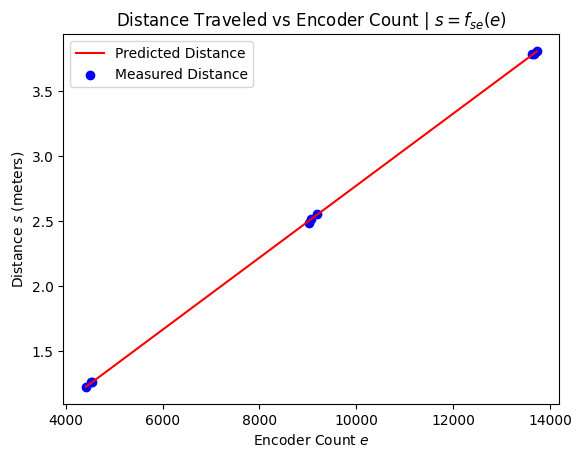

In [4]:
import numpy as np
from numpy.polynomial import Polynomial

x_data = np.array(x_data, dtype=np.float64)
y_data = np.array(y_data, dtype=np.float64)

# Add (0, 0) to the data
# x_data = np.array([0, *x_data])
# y_data = np.array([0, *y_data])

# Design matrix for degree 2 without constant term
X = np.vstack([x_data, x_data**2]).T  # columns: x, x^2

# Solve least squares
coeffs = np.linalg.lstsq(X, y_data, rcond=None)[0]

# Create polynomial (c0 = 0)
p = Polynomial([0, *coeffs])  # c0=0, c1=coeffs[0], c2=coeffs[1]

y_pre = p(x_data)

print("Coefficients:", p.coef)
# print equation
print(f"Fitted Polynomial: s = {p.coef[0]:.6f} * e + {p.coef[1]:.6e} * e^2")
plt.plot(x_data, y_pre, label='Predicted Distance', color='red')
plt.scatter(x_data, y_data, label='Measured Distance', color='blue')
plt.legend()

plt.xlabel(f'Encoder Count $e$')
plt.ylabel(f'Distance $s$ (meters)')
plt.title(f'Distance Traveled vs Encoder Count | $s = f_{{se}}(e)$')

# Show plot in notebook
plt.show()


In [5]:
#  Standard deviation of errors
sigma2 = (y_data - y_pre) ** 2

print(sigma2)

# plt.plot(x_data, sigma2, marker='o')
# plt.xlabel(f'Encoder Count $e$')
# plt.ylabel(f'Error Variance $\sigma_s^2$')
# plt.title('Error Variance vs Encoder Count')
# plt.show()

[3.47315386e-07 1.25108456e-05 3.27773336e-05 2.38820159e-04
 1.15725559e-06 3.49535741e-05 2.11300255e-05 3.84863097e-05
 1.79937881e-05]


Error Coefficients: [ 9.18891980e-05  5.50499436e-06 -7.34909627e-05]
Fitted Polynomial for Error Variance: σ² = 9.188920e-05 * e^2 + 5.504994e-06 * e + -7.349096e-05


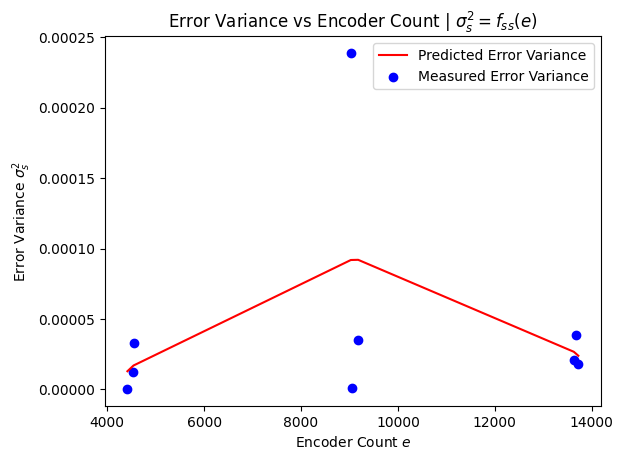

In [6]:
p = Polynomial.fit(x_data, sigma2, deg=2)
print("Error Coefficients:", p.coef)
print(f"Fitted Polynomial for Error Variance: σ² = {p.coef[0]:.6e} * e^2 + {p.coef[1]:.6e} * e + {p.coef[2]:.6e}")
y_fit = p(x_data)

plt.plot(x_data, y_fit, label='Predicted Error Variance', color='red')
plt.scatter(x_data, sigma2, marker='o', label='Measured Error Variance', color='blue')
plt.xlabel(f'Encoder Count $e$')
plt.ylabel(f'Error Variance $\sigma_s^2$')
plt.title(f'Error Variance vs Encoder Count | $\sigma_s^2 = f_{{ss}}(e)$')
plt.legend()
plt.show()
